<a href="https://colab.research.google.com/github/SudeepDahal17/Openseespy/blob/main/Copy_of_Pushover_Accurate_Gemini.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

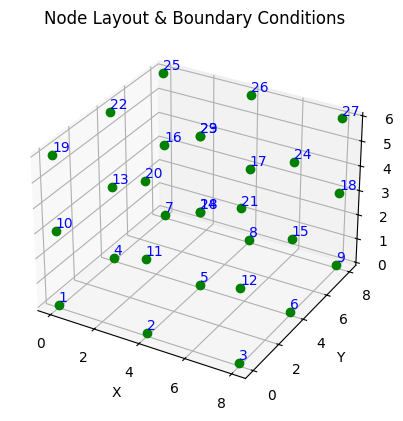

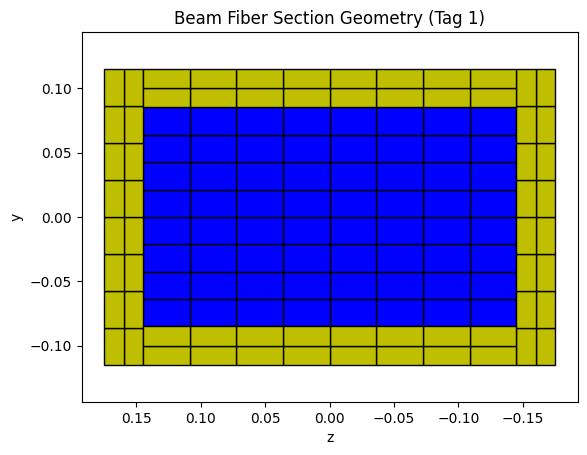

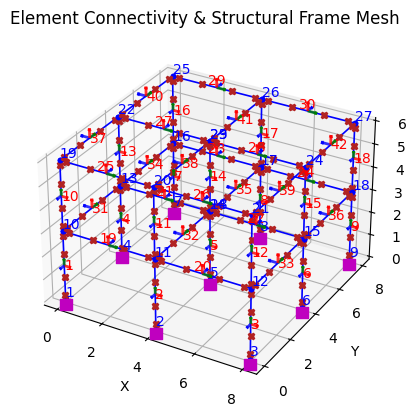


EIGENVALUE / MODAL ANALYSIS RESULTS
Mode 1:  omega^2 = 515.7693 rad2/s2  |  omega = 22.7106 rad/s  |  f = 3.6145 Hz  |  T = 0.2767 s
Mode 2:  omega^2 = 516.2294 rad2/s2  |  omega = 22.7207 rad/s  |  f = 3.6161 Hz  |  T = 0.2765 s
Mode 3:  omega^2 = 707.8577 rad2/s2  |  omega = 26.6056 rad/s  |  f = 4.2344 Hz  |  T = 0.2362 s



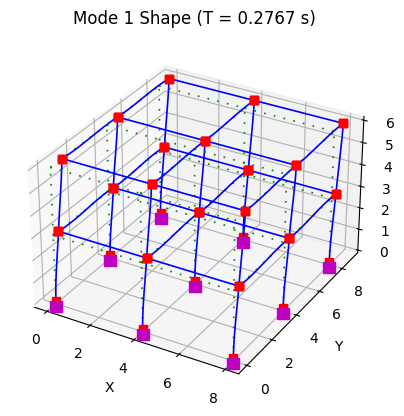

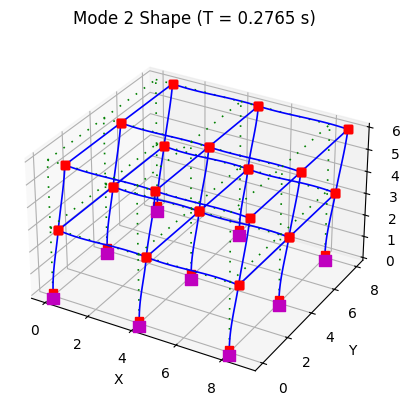

Gravity Analysis Status: SUCCESS


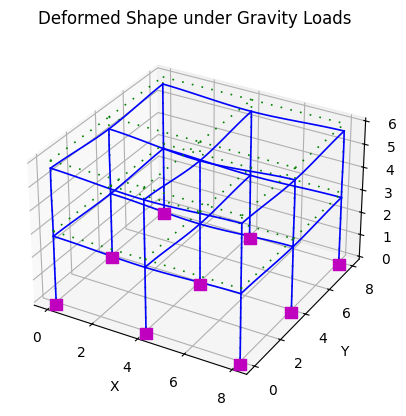


Starting Pushover Analysis in X-Direction...


WARNING can't set handler after analysis is created


Pushover Analysis Complete! Max Drift Reached: 0.4800 m (8.00%)


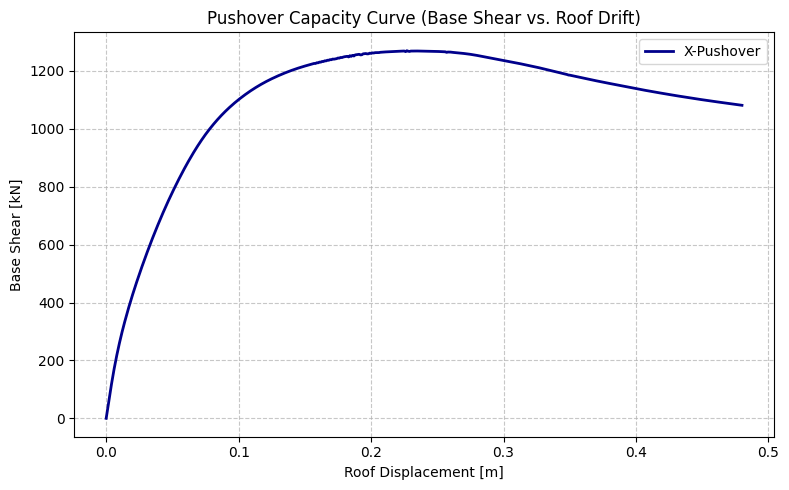

In [ ]:
!pip install openseespy
!pip install opsvis matplotlib
import math
import matplotlib.pyplot as plt
import openseespy.opensees as ops
import opsvis as opsv

# ============================================================
# 0. RESET & MODEL SETUP
# ============================================================
ops.wipe()
ops.model('basic', '-ndm', 3, '-ndf', 6)

# ------------------------------------------------------------
# 1. Geometry & Material Properties
# ------------------------------------------------------------
bayX, bayY = 4.0, 4.0
nBayX, nBayY = 2, 2
storyHeight = 3.0
nStory = 2

Ec = 25e9  # Pa
rho = 2500  # kg/m3
nu = 0.2
G = Ec / (2 * (1 + nu))

# Beam Section
Bb, Hb = 0.23, 0.35
Ab = Bb * Hb
Jb = (Bb * Hb**3 / 3.0) * (1 - 0.63 * (Bb / Hb) + 0.052 * (Bb / Hb) ** 5)

# Column Section
Bc, Hc = 0.35, 0.35
Ac = Bc * Hc
Jc = (Bc * Hc**3 / 3.0) * (1 - 0.63 * (Bc / Hc) + 0.052 * (Bc / Hc) ** 5)

# ------------------------------------------------------------
# 2. Nodes & Boundary Conditions
# ------------------------------------------------------------
nodeTag = 1
nodeMap = {}
baseNodes = []

for story in range(nStory + 1):
    z = story * storyHeight
    for row in range(nBayY + 1):
        y = row * bayY
        for col in range(nBayX + 1):
            x = col * bayX

            ops.node(nodeTag, x, y, z)
            nodeMap[(col, row, story)] = nodeTag

            if story == 0:
                ops.fix(nodeTag, 1, 1, 1, 1, 1, 1)  # Fixed base
                baseNodes.append(nodeTag)

            nodeTag += 1

# Master Diaphragm Nodes
masterNodes = {}
masterTag = nodeTag

for k in range(1, nStory + 1):
    z = k * storyHeight
    ops.node(masterTag, bayX * nBayX / 2, bayY * nBayY / 2, z)
    # CRITICAL: Fix UZ, RX, RY. Keep UX, UY, RZ FREE for rigid floor motion!
    ops.fix(masterTag, 0, 0, 1, 1, 1, 0)
    masterNodes[k] = masterTag
    masterTag += 1

# Rigid Diaphragm Constraints
for k in range(1, nStory + 1):
    master = masterNodes[k]
    slaveNodes = [
        nodeMap[(i, j, k)]
        for j in range(nBayY + 1)
        for i in range(nBayX + 1)
    ]
    ops.rigidDiaphragm(3, master, *slaveNodes)

# ============================================================
# VISUALIZATION 1: NODE VISUALIZATION
# ============================================================
opsv.plot_model(node_labels=True)
plt.title('Node Layout & Boundary Conditions')
plt.show()

# ------------------------------------------------------------
# 3. Geometric Transformations
# ------------------------------------------------------------
ops.geomTransf('PDelta', 1, 1.0, 0.0, 0.0)  # Columns
ops.geomTransf('PDelta', 2, 0.0, 0.0, 1.0)  # Beams X
ops.geomTransf('PDelta', 3, 0.0, 0.0, 1.0)  # Beams Y

# ------------------------------------------------------------
# 4. Materials & Fiber Sections
# ------------------------------------------------------------
ops.uniaxialMaterial(
    'Concrete02', 1, -25e6, -0.002, -0.8 * 25e6, -0.0035, 0.1, 2.5e6, 200e6
)
ops.uniaxialMaterial(
    'Concrete02', 2, -30e6, -0.003, -25e6, -0.008, 0.1, 2.5e6, 200e6
)
ops.uniaxialMaterial('Steel02', 3, 415e6, 200e9, 0.01)

# Beam Section
cover_b, barDia_b = 0.03, 0.012
barArea_b = math.pi * barDia_b**2 / 4
coreB_b, coreH_b = Bb - 2 * cover_b, Hb - 2 * cover_b

ops.section('Fiber', 1, '-GJ', 0.2 * G * Jb)
ops.patch(
    'rect', 2, 8, 8, -coreB_b / 2, -coreH_b / 2, coreB_b / 2, coreH_b / 2
)
ops.patch('rect', 1, 8, 2, -Bb / 2, -Hb / 2, Bb / 2, -coreH_b / 2)
ops.patch('rect', 1, 8, 2, -Bb / 2, coreH_b / 2, Bb / 2, Hb / 2)
ops.patch('rect', 1, 2, 8, -Bb / 2, -coreH_b / 2, -coreB_b / 2, coreH_b / 2)
ops.patch('rect', 1, 2, 8, coreB_b / 2, -coreH_b / 2, Bb / 2, coreH_b / 2)

yTop_b, yBot_b = Hb / 2 - cover_b - barDia_b / 2, -Hb / 2 + cover_b + barDia_b / 2
for x_pos in [
    -Bb / 2 + cover_b + barDia_b / 2,
    0.0,
    Bb / 2 - cover_b - barDia_b / 2,
]:
    ops.fiber(x_pos, yTop_b, barArea_b, 3)
    ops.fiber(x_pos, yBot_b, barArea_b, 3)

# Column Section
cover_c, barDia_c = 0.04, 0.016
barArea_c = math.pi * barDia_c**2 / 4
coreB_c, coreH_c = Bc - 2 * cover_c, Hc - 2 * cover_c

ops.section('Fiber', 2, '-GJ', 0.2 * G * Jc)
ops.patch(
    'rect', 2, 8, 8, -coreB_c / 2, -coreH_c / 2, coreB_c / 2, coreH_c / 2
)
ops.patch('rect', 1, 8, 2, -Bc / 2, -Hc / 2, Bc / 2, -coreH_c / 2)
ops.patch('rect', 1, 8, 2, -Bc / 2, coreH_c / 2, Bc / 2, Hc / 2)
ops.patch('rect', 1, 2, 8, -Bc / 2, -coreH_c / 2, -coreB_c / 2, coreH_c / 2)
ops.patch('rect', 1, 2, 8, coreB_c / 2, -coreH_c / 2, Bc / 2, coreH_c / 2)

offset_c = Bc / 2 - cover_c - barDia_c / 2
col_bars = [
    (-offset_c, -offset_c),
    (0, -offset_c),
    (offset_c, -offset_c),
    (-offset_c, offset_c),
    (0, offset_c),
    (offset_c, offset_c),
    (-offset_c, 0),
    (offset_c, 0),
]
for x_pos, y_pos in col_bars:
    ops.fiber(x_pos, y_pos, barArea_c, 3)

# ============================================================
# VISUALIZATION 3: BEAM AND COLUMN SECTION VISUALIZATION
# ============================================================

# Define Beam Fiber Section Data Structure for opsvis
fib_sec_beam = [
    # Core Concrete Patch
    ['patch', 'rect', 2, 8, 8, -coreB_b / 2, -coreH_b / 2, coreB_b / 2, coreH_b / 2],
    # Cover Concrete Patches
    ['patch', 'rect', 1, 8, 2, -Bb / 2, -Hb / 2, Bb / 2, -coreH_b / 2],
    ['patch', 'rect', 1, 8, 2, -Bb / 2, coreH_b / 2, Bb / 2, Hb / 2],
    ['patch', 'rect', 1, 2, 8, -Bb / 2, -coreH_b / 2, -coreB_b / 2, coreH_b / 2],
    ['patch', 'rect', 1, 2, 8, coreB_b / 2, -coreH_b / 2, Bb / 2, coreH_b / 2],
    # Reinforcing Bar Fibers [ 'fiber', yLoc, zLoc, area, matTag ]
    ['fiber', yTop_b, -Bb / 2 + cover_b + barDia_b / 2, barArea_b, 3],
    ['fiber', yTop_b, 0.0, barArea_b, 3],
    ['fiber', yTop_b, Bb / 2 - cover_b - barDia_b / 2, barArea_b, 3],
    ['fiber', yBot_b, -Bb / 2 + cover_b + barDia_b / 2, barArea_b, 3],
    ['fiber', yBot_b, 0.0, barArea_b, 3],
    ['fiber', yBot_b, Bb / 2 - cover_b - barDia_b / 2, barArea_b, 3]
]

# Plot Beam Section
opsv.plot_fiber_section(fib_sec_beam)
plt.title('Beam Fiber Section Geometry (Tag 1)')
plt.show()

# ------------------------------------------------------------
# 5. Element Assignment
# ------------------------------------------------------------
ops.beamIntegration('Legendre', 1, 1, 4)
ops.beamIntegration('Legendre', 2, 2, 4)

eleTag = 1
beamTags, columnTags = [], []

# Columns
for k in range(nStory):
    for j in range(nBayY + 1):
        for i in range(nBayX + 1):
            n1, n2 = nodeMap[(i, j, k)], nodeMap[(i, j, k + 1)]
            ops.element('dispBeamColumn', eleTag, n1, n2, 1, 2)
            columnTags.append(eleTag)
            eleTag += 1

# Beams X
for k in range(1, nStory + 1):
    for j in range(nBayY + 1):
        for i in range(nBayX):
            n1, n2 = nodeMap[(i, j, k)], nodeMap[(i + 1, j, k)]
            ops.element('dispBeamColumn', eleTag, n1, n2, 2, 1)
            beamTags.append(eleTag)
            eleTag += 1

# Beams Y
for k in range(1, nStory + 1):
    for j in range(nBayY):
        for i in range(nBayX + 1):
            n1, n2 = nodeMap[(i, j, k)], nodeMap[(i, j + 1, k)]
            ops.element('dispBeamColumn', eleTag, n1, n2, 3, 1)
            beamTags.append(eleTag)
            eleTag += 1

# ============================================================
# VISUALIZATION 2: ELEMENT CONNECTION VISUALIZATION
# ============================================================
opsv.plot_model(element_labels=True)
plt.title('Element Connectivity & Structural Frame Mesh')
plt.show()

# ------------------------------------------------------------
# MASS ASSIGNMENT & EIGENVALUE ANALYSIS (ADDED)
# ------------------------------------------------------------
g = 9.81  # Acceleration due to gravity (m/s2)

gammaConcrete = 25e3
beamLoad = (gammaConcrete * Bb * Hb) + 9e3
columnSelfWeight = gammaConcrete * Bc * Hc
slabThickness, floorFinish, liveLoad = 0.125, 1e3, 2e3
floorLoad = (slabThickness * gammaConcrete) + floorFinish + liveLoad

# Assign Translational Lumped Mass to Floor Nodes (m = Force / g)
for k in range(1, nStory + 1):
    for j in range(nBayY + 1):
        for i in range(nBayX + 1):
            tribArea = bayX * bayY
            if i in [0, nBayX]:
                tribArea *= 0.5
            if j in [0, nBayY]:
                tribArea *= 0.5

            # Tributary vertical load -> Lumped mass
            nodalLoad = floorLoad * tribArea
            nodalMass = nodalLoad / g

            node_id = nodeMap[(i, j, k)]
            ops.mass(node_id, nodalMass, nodalMass, nodalMass, 0.0, 0.0, 0.0)

# Perform Eigenvalue Analysis for 3 Modes
numModes = 3
eigenValues = ops.eigen(numModes)

print("\n" + "="*50)
print("EIGENVALUE / MODAL ANALYSIS RESULTS")
print("="*50)

periods = []
for idx, w2 in enumerate(eigenValues):
    w = math.sqrt(w2)
    f = w / (2 * math.pi)
    T = 1.0 / f
    periods.append(T)
    print(f"Mode {idx+1}:  omega^2 = {w2:.4f} rad2/s2  |  omega = {w:.4f} rad/s  |  f = {f:.4f} Hz  |  T = {T:.4f} s")
print("="*50 + "\n")

# ============================================================
# VISUALIZATION: MODAL SHAPES
# ============================================================
# ============================================================
# VISUALIZATION: MODAL SHAPES (FIXED)
# ============================================================
opsv.plot_mode_shape(1)
plt.title(f'Mode 1 Shape (T = {periods[0]:.4f} s)')
plt.show()

opsv.plot_mode_shape(2)
plt.title(f'Mode 2 Shape (T = {periods[1]:.4f} s)')
plt.show()

# ------------------------------------------------------------
# 6. Gravity Load Application
# ------------------------------------------------------------
ops.timeSeries('Linear', 1)
ops.pattern('Plain', 1, 1)

for ele in beamTags:
    nI, nJ = ops.eleNodes(ele)
    x1, y1, z1 = ops.nodeCoord(nI)
    x2, y2, z2 = ops.nodeCoord(nJ)
    L = math.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)
    P = beamLoad * L / 2
    ops.load(nI, 0.0, 0.0, -P, 0.0, 0.0, 0.0)
    ops.load(nJ, 0.0, 0.0, -P, 0.0, 0.0, 0.0)

# Apply column self-weight to nodes in Gravity Load Pattern
for ele in columnTags:
    nI, nJ = ops.eleNodes(ele)
    # Column weight = length (3.0m) * columnSelfWeight
    P_col = 3.0 * columnSelfWeight / 2.0  # Half to node I, half to node J

    # Add downward vertical load (Z-direction)
    ops.load(nI, 0.0, 0.0, -P_col, 0.0, 0.0, 0.0)
    ops.load(nJ, 0.0, 0.0, -P_col, 0.0, 0.0, 0.0)


for k in range(1, nStory + 1):
    for j in range(nBayY + 1):
        for i in range(nBayX + 1):
            tribArea = bayX * bayY
            if i in [0, nBayX]:
                tribArea *= 0.5
            if j in [0, nBayY]:
                tribArea *= 0.5
            P = floorLoad * tribArea
            ops.load(nodeMap[(i, j, k)], 0.0, 0.0, -P, 0.0, 0.0, 0.0)

ops.system('BandGeneral')
ops.numberer('RCM')
ops.constraints('Transformation')
ops.test('NormDispIncr', 1e-6, 50)
ops.algorithm('Newton')
ops.integrator('LoadControl', 0.1)
ops.analysis('Static')

gravityStatus = ops.analyze(10)
print(
    'Gravity Analysis Status:',
    'SUCCESS' if gravityStatus == 0 else 'FAILED',
)

ops.loadConst('-time', 0.0)

# ============================================================
# VISUALIZATION 4: DEFORMED SHAPE AFTER GRAVITY APPLICATION
# ============================================================
opsv.plot_defo()
plt.title('Deformed Shape under Gravity Loads')
plt.show()

# ------------------------------------------------------------
# 7. NONLINEAR STATIC PUSHOVER ANALYSIS (CORRECTED)
# ------------------------------------------------------------
print('\nStarting Pushover Analysis in X-Direction...')

ops.timeSeries('Linear', 2)
ops.pattern('Plain', 2, 2)

# Apply lateral load pattern directly to MASTER NODES
totalH = nStory * storyHeight
for k in range(1, nStory + 1):
    z = k * storyHeight
    F_lateral = z / totalH
    ops.load(masterNodes[k], F_lateral, 0.0, 0.0, 0.0, 0.0, 0.0)

# CRITICAL FIX: Control Node MUST be the Master Diaphragm Node
controlNode = masterNodes[nStory]
controlDOF = 1  # UX
targetDisp = 0.08 * totalH  # 6% Drift limit (0.3 m)
dU = 0.001  # 1 mm step size
maxSteps = int(targetDisp / dU)

# Re-initialize static analysis parameters for pushover
ops.system('BandGeneral')
ops.numberer('RCM')
ops.constraints('Transformation')
ops.test('NormDispIncr', 1e-4, 100, 0)
ops.algorithm('KrylovNewton')
ops.integrator('DisplacementControl', controlNode, controlDOF, dU)
ops.analysis('Static')

dispResult = [0.0]
baseShearResult = [0.0]

for step in range(1, maxSteps + 1):
    ok = ops.analyze(1)

    if ok != 0:
        # Fallback to Newton with Line Search if Krylov has step convergence issues
        ops.algorithm('NewtonLineSearch', 0.8)
        ok = ops.analyze(1)
        ops.algorithm('KrylovNewton')

    if ok != 0:
        print(f'Pushover stopped early at step {step}/{maxSteps}.')
        break

    uX = ops.nodeDisp(controlNode, controlDOF)
    ops.reactions()
    Vb = sum(ops.nodeReaction(bNode, 1) for bNode in baseNodes)

    dispResult.append(uX)
    baseShearResult.append(-Vb / 1000.0)  # N to kN

print(
    f'Pushover Analysis Complete! Max Drift Reached:'
    f' {dispResult[-1]:.4f} m ({dispResult[-1]/totalH*100:.2f}%)'
)

# ------------------------------------------------------------
# 8. PLOT CAPACITY CURVE
# ------------------------------------------------------------
plt.figure(figsize=(8, 5))
plt.plot(
    dispResult,
    baseShearResult,
    color='darkblue',
    linewidth=2,
    label='X-Pushover',
)
plt.title('Pushover Capacity Curve (Base Shear vs. Roof Drift)')
plt.xlabel('Roof Displacement [m]')
plt.ylabel('Base Shear [kN]')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()